# 10 - IO.zarr: do the environmental variables change the smudging?

Diagnostic for the question of whether the big smooth fills the model leaves in large gaps ("smudging") are
caused by the model's inputs or are intrinsic to the approach. This runs the current self-supervised pipeline
on the original IO.zarr Indian Ocean cube, which is the only dataset that carries the physical environmental
variables (`sst`, `u_wind`, `v_wind`, `air_temp`) that PACE and Copernicus do not have.

Two configs are trained on the same data with the same fake clouds, so they are directly comparable:

- **chl**: the current channel set, chlorophyll-derived plus position and season (masked CHL, previous and
  next day, day-of-year, geo x/y/z, flags). This is what the PACE and Copernicus models use.
- **env**: the same, plus the standardized physical predictors `sst`, `u_wind`, `v_wind`, `air_temp`.

If **env** fills the large gaps with more structure than **chl**, then the smudging in PACE and Copernicus is
largely a missing-predictor problem (those stores lack SST and winds), not a bug in the code. If both smudge
the same, the smudging is intrinsic to the MSE gap-fill and points to a loss or model change instead. The
scored metric is held-out fake-cloud MAE; the qualitative read is the large real gaps, which have no truth
here but show the fill behavior directly.

## Setup

In [1]:
%pip install --force-reinstall --no-cache-dir "git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch"
!pip install -qU zarr

  Cloning https://github.com/SAFS-Varanasi-Internship/mindthegap.git (to revision troy-branch) to /tmp/pip-req-build-pe9a8q_f
  Running command git clone --filter=blob:none --quiet https://github.com/SAFS-Varanasi-Internship/mindthegap.git /tmp/pip-req-build-pe9a8q_f
  Running command git checkout -b troy-branch --track origin/troy-branch
  Switched to a new branch 'troy-branch'
  branch 'troy-branch' set up to track 'origin/troy-branch'.
  Resolved https://github.com/SAFS-Varanasi-Internship/mindthegap.git to commit a283618275b3526b8f73a62badfb7c0857fc11b4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.1.0-py3-none-any.whl size=29541 sha256=57a4fc15c493d9d66a6d88ed9a28958a0ce3d77c1c87449e217b5a9c6e30a449
  Stored in directory: /tmp/pip-ephem-wheel-cache-ov_h64c4/wheels/a1/29/be/8f08433dabdc0a094cca6252bb0690294de2dc915077b47a8e
Successfully buil

In [2]:
import os
import numpy as np, pandas as pd
import xarray as xr
import tensorflow as tf
from scipy import ndimage
import matplotlib.pyplot as plt
import mindthegap as mtg

for _g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_g, True)

WORKDIR = os.path.expanduser("~/shared-public/mindthegap")
CACHE_DIR = f"{WORKDIR}/cache"; MODEL_DIR = f"{WORKDIR}/models"
os.makedirs(CACHE_DIR, exist_ok=True); os.makedirs(MODEL_DIR, exist_ok=True)

def save_png(name, **kw):
    try:
        plt.savefig(name, **kw)
    except OSError as e:
        print("savefig skipped (", e, ")")

bpc = mtg.build_pace_channels

2026-08-06 20:41:48.049710: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-06 20:41:48.249538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786048908.277976   12767 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786048908.288753   12767 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786048908.466802   12767 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Load IO.zarr (recent dense window)

The store spans 1997 to 2022 daily. We take the most recent `NT` frames, which are the dense multi-sensor
years, log the level-3 chlorophyll, and keep the physical variables as-is. Ocean is where SST is ever finite
(SST is defined over ocean only), and land is passed into the channel builder so it never scores land.

In [3]:
IO_PATH = "/home/jovyan/shared-public/mindthegap/data/IO_rechunked.zarr"
CHLVAR = "CHL_cmes-level3"                                   # the gappy L3 field we gap-fill
FEATS = ["sst", "u_wind", "v_wind", "air_temp"]             # physical predictors, only present in this store
NT = 730                                                     # most recent daily frames (~2 years)

CACHE = f"{CACHE_DIR}/io_last{NT}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    chl_log = z["chl_log"]; feats = z["feats"]; times = z["times"]; LATV = z["LATV"]; LONV = z["LONV"]
    print("reused", CACHE)
else:
    ds_io = xr.open_zarr(IO_PATH).isel(time=slice(-NT, None))
    nlat, nlon = ds_io.sizes["lat"], ds_io.sizes["lon"]
    cy, cx = slice(0, nlat - nlat % 8), slice(0, nlon - nlon % 8)   # crop to multiple of 8 (three 2x pools)
    ds_io = ds_io.isel(lat=cy, lon=cx)
    chl = ds_io[CHLVAR].values.astype("float32")
    chl_log = np.log(np.where(chl > 0, chl, np.nan)).astype("float32")
    feats = np.stack([ds_io[f].values.astype("float32") for f in FEATS], 0)   # (F, T, H, W)
    times = ds_io.time.values; LATV = ds_io.lat.values; LONV = ds_io.lon.values
    np.savez(CACHE, chl_log=chl_log, feats=feats, times=times, LATV=LATV, LONV=LONV)
    print("saved", CACHE)

T, H, W = chl_log.shape
ocean = np.isfinite(feats[0]).any(0)                        # SST defines ocean
cov = float(np.mean([np.isfinite(chl_log[t])[ocean].mean() for t in range(T)]))
print(f"IO.zarr {H}x{W}, {T} frames  |  {str(times[0])[:10]} -> {str(times[-1])[:10]}")
print(f"ocean {ocean.mean():.0%}  |  mean CHL coverage per frame {cov:.0%}")

reused /home/jovyan/shared-public/mindthegap/cache/io_last730.npz
IO.zarr 176x240, 730 frames  |  2021-01-01 -> 2022-12-31
ocean 65%  |  mean CHL coverage per frame 51%


## Config and channels

One `build_pace_channels` call builds the chlorophyll base channels and the fake clouds for the whole cube.
Both configs reuse that single call, so they hide exactly the same pixels and the comparison is fair. The
`env` config appends the four physical predictors, each standardized on the training frames over ocean.

In [4]:
COVERAGE = 0.2           # fraction of observed pixels hidden as fake clouds for the held-out score
BLOB_SIGMA = 12          # fake-cloud size in pixels; large enough to create sizeable held-out gaps
N_DAYS = 1               # one previous and one next frame
EPOCHS = 40; BATCH = 8

rng0 = np.random.default_rng(0)
perm = rng0.permutation(T); ntr = int(0.8 * T)
tr = np.zeros(T, bool); tr[perm[:ntr]] = True; va = ~tr
print("split -> train", int(tr.sum()), "val", int(va.sum()))

ch, y, STATS, ORDER = bpc(chl_log, times, tr, n_days=N_DAYS, cloud_mode="synthetic",
                          coverage=COVERAGE, blob_sigma=BLOB_SIGMA, time_sigma=1.5, seed=0, land=~ocean)
Y_MEAN, Y_STD = STATS["CHL"]
fake = ch["fake_cloud_flag"].astype(bool)
Y = np.stack([np.nan_to_num(y, nan=0.0), ch["fake_cloud_flag"]], -1).astype("float32")   # [value, loss-mask]

def geo_full():
    la = np.deg2rad(LATV)[:, None]; lo = np.deg2rad(LONV)[None, :]
    return np.stack([np.broadcast_to(np.cos(la) * np.cos(lo), (H, W)),
                     np.broadcast_to(np.cos(la) * np.sin(lo), (H, W)),
                     np.broadcast_to(np.sin(la), (H, W))], -1).astype("float32")

def std_feat(arr):
    sub = arr[tr][:, ocean]
    m = float(np.nanmean(sub)); s = float(np.nanstd(sub)) + 1e-6
    return np.nan_to_num((arr - m) / s, nan=0.0).astype("float32")

BASE = np.concatenate([np.stack([ch[k] for k in ORDER], -1),
                       np.broadcast_to(geo_full()[None], (T, H, W, 3))], -1).astype("float32")
ENV = np.stack([std_feat(feats[i]) for i in range(len(FEATS))], -1).astype("float32")   # (T,H,W,4)

def make_X(cfg):                                          # build one config's stack on demand, not both at once
    return BASE if cfg == "chl" else np.concatenate([BASE, ENV], -1).astype("float32")
print("channels  chl:", BASE.shape[-1], " env:", BASE.shape[-1] + ENV.shape[-1], f"(+{len(FEATS)} physical)")

split -> train 584 val 146
channels  chl: 12  env: 16 (+4 physical)


## Train both configs

In [5]:
models = {}; pred = {}
for cfg in ["chl", "env"]:
    Xc = make_X(cfg)                                      # one config in memory at a time
    path = f"{MODEL_DIR}/io_{H}x{W}_{T}_feat-{cfg}.keras"
    if os.path.exists(path):
        print("load", path); models[cfg] = tf.keras.models.load_model(path, compile=False)
    else:
        m = mtg.UNet((None, None, Xc.shape[-1])); m.compile("adam", loss=mtg.masked_mse, jit_compile=False)
        es = tf.keras.callbacks.EarlyStopping("val_loss", patience=6, restore_best_weights=True)
        m.fit(Xc[tr], Y[tr], validation_data=(Xc[va], Y[va]),
              epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=2)
        m.save(path); models[cfg] = m; print("saved", path)
    pred[cfg] = models[cfg].predict(Xc, batch_size=BATCH, verbose=0)[..., 0] * Y_STD + Y_MEAN
    del Xc
print("ready:", list(models))

load /home/jovyan/shared-public/mindthegap/models/io_176x240_730_feat-chl.keras


2026-08-06 20:42:17.926185: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-06 20:42:18.721665: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,176,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,12,176,240]{3,2,1,0} %bitcast.688, f32[64,12,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input

load /home/jovyan/shared-public/mindthegap/models/io_176x240_730_feat-env.keras


2026-08-06 20:42:35.663417: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,176,240]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,16,176,240]{3,2,1,0} %bitcast.688, f32[64,16,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-08-06 20:42:35.728974: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potenti

ready: ['chl', 'env']


## Held-out fake-cloud MAE

Scored only on the hidden fake-cloud pixels over ocean, in log chlorophyll, pooled over validation frames.
Nearest-neighbor (fill each hidden pixel from its closest un-hidden pixel) is shown as the trivial spatial
baseline, and persistence (yesterday's value, where it survives the fake clouds) as the temporal one.

In [6]:
def nn_fill(truth, observed):
    if not observed.any(): return np.full_like(truth, np.nan)
    _, (iy, ix) = ndimage.distance_transform_edt(~observed, return_indices=True)
    return np.where(observed, truth, np.nan)[iy, ix]

val = np.where(va)[0]
rows = {k: [] for k in ["chl", "env", "nn", "pers"]}
for d in val:
    if d < 1: continue
    truth = chl_log[d]
    held = fake[d] & ocean & np.isfinite(truth)
    if not held.any(): continue
    nn = nn_fill(truth, ocean & ~fake[d] & np.isfinite(truth))
    prev = np.where(fake[d - 1], np.nan, chl_log[d - 1]); hp = held & np.isfinite(prev)
    rows["chl"].extend(np.abs(pred["chl"][d][held] - truth[held]))
    rows["env"].extend(np.abs(pred["env"][d][held] - truth[held]))
    rows["nn"].extend(np.abs(nn[held] - truth[held]))
    rows["pers"].extend(np.abs(prev[hp] - truth[hp]))
print(f"{'config':>12} {'held-out MAE':>14}")
for k in ["chl", "env", "nn", "pers"]:
    print(f"{k:>12} {np.mean(rows[k]):>14.4f}   (n={len(rows[k])})")

      config   held-out MAE
         chl         0.1694   (n=366861)
         env         0.1620   (n=366861)
          nn         0.2975   (n=366861)
        pers         0.1353   (n=63130)


## Big-gap fills: chl vs env, side by side

The scored pixels are small fake-cloud blobs. The real test for smudging is the large native gaps, which have
no truth to score but show the fill behavior directly. This picks the validation frame with the most missing
ocean and shows the input, both fills, and the SST field the `env` model can lean on. If `env` recovers
structure where `chl` goes flat, the physical predictors are what break the smudge.

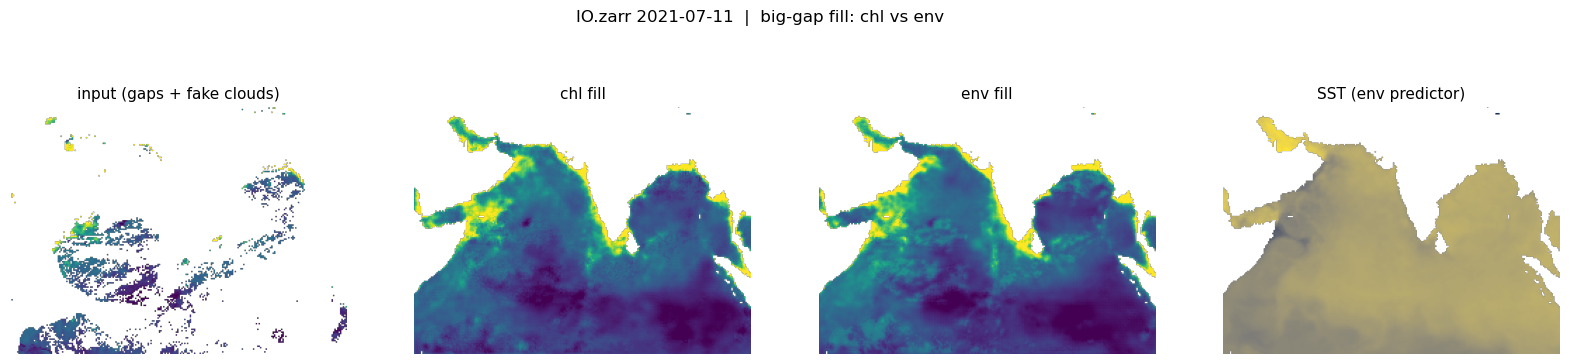

In [7]:
gap = [(d, int((~np.isfinite(chl_log[d]) & ocean).sum())) for d in val]
d = max(gap, key=lambda t: t[1])[0]
truth = chl_log[d]
vlo, vhi = np.nanpercentile(truth[ocean][np.isfinite(truth[ocean])], [2, 98])
panels = [("input (gaps + fake clouds)", np.where(np.isfinite(truth) & ~fake[d], truth, np.nan), vlo, vhi, "viridis"),
          ("chl fill", np.where(ocean, pred["chl"][d], np.nan), vlo, vhi, "viridis"),
          ("env fill", np.where(ocean, pred["env"][d], np.nan), vlo, vhi, "viridis"),
          ("SST (env predictor)", np.where(ocean, feats[0][d], np.nan), None, None, "cividis")]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, (ttl, arr, lo, hi, cm) in zip(axes, panels):
    ax.imshow(arr, cmap=cm, vmin=lo, vmax=hi, origin="upper"); ax.set_title(ttl, fontsize=11); ax.axis("off")
plt.suptitle(f"IO.zarr {str(pd.to_datetime(times[d]).date())}  |  big-gap fill: chl vs env", y=1.02)
save_png("io_env_biggap.png", dpi=120, bbox_inches="tight"); plt.show()

### Comparison across 12 days, with the Copernicus L4 gap-free product

The 12 validation frames with the largest missing-ocean area. Each row is one day: the input (gaps and fake
clouds hidden), the chl and env fills, and the Copernicus L4 gap-free product as the operational reference,
the same product the earlier notebooks compared against. The gap-free field is not in the rechunked cube, so
it is loaded from the original IO.zarr; if that store is unreachable the column is dropped and the panel shows
the three model columns. It is a reference fill, not independent truth, since it is itself a gap-filled
product.

In [8]:
# Copernicus L4 gap-free product (CHL_cmes-gapfree). The rechunked cube does not carry it, so load it from the
# original IO.zarr, matched to the same recent window and cropped grid. Assumes the same time axis as above.
FILLED_SRCS = [os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr"),   # local original
               "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr"]        # public GCS fallback
filled_log = None
for _src in FILLED_SRCS:
    try:
        fds = xr.open_zarr(_src).isel(time=slice(-NT, None))
        fnl, fnw = fds.sizes["lat"], fds.sizes["lon"]
        fds = fds.isel(lat=slice(0, fnl - fnl % 8), lon=slice(0, fnw - fnw % 8))
        _gf = fds["CHL_cmes-gapfree"].values.astype("float32")
        filled_log = np.log(np.where(_gf > 0, _gf, np.nan)).astype("float32")
        print("loaded L4 gap-free from", _src, filled_log.shape); break
    except Exception as e:
        print("could not load gap-free from", _src, "-", repr(e)[:110])
if filled_log is None:
    print("L4 gap-free not available; the Copernicus column will be dropped from the panel.")

loaded L4 gap-free from /home/jovyan/shared/mind_the_chl_gap/IO.zarr (730, 176, 240)


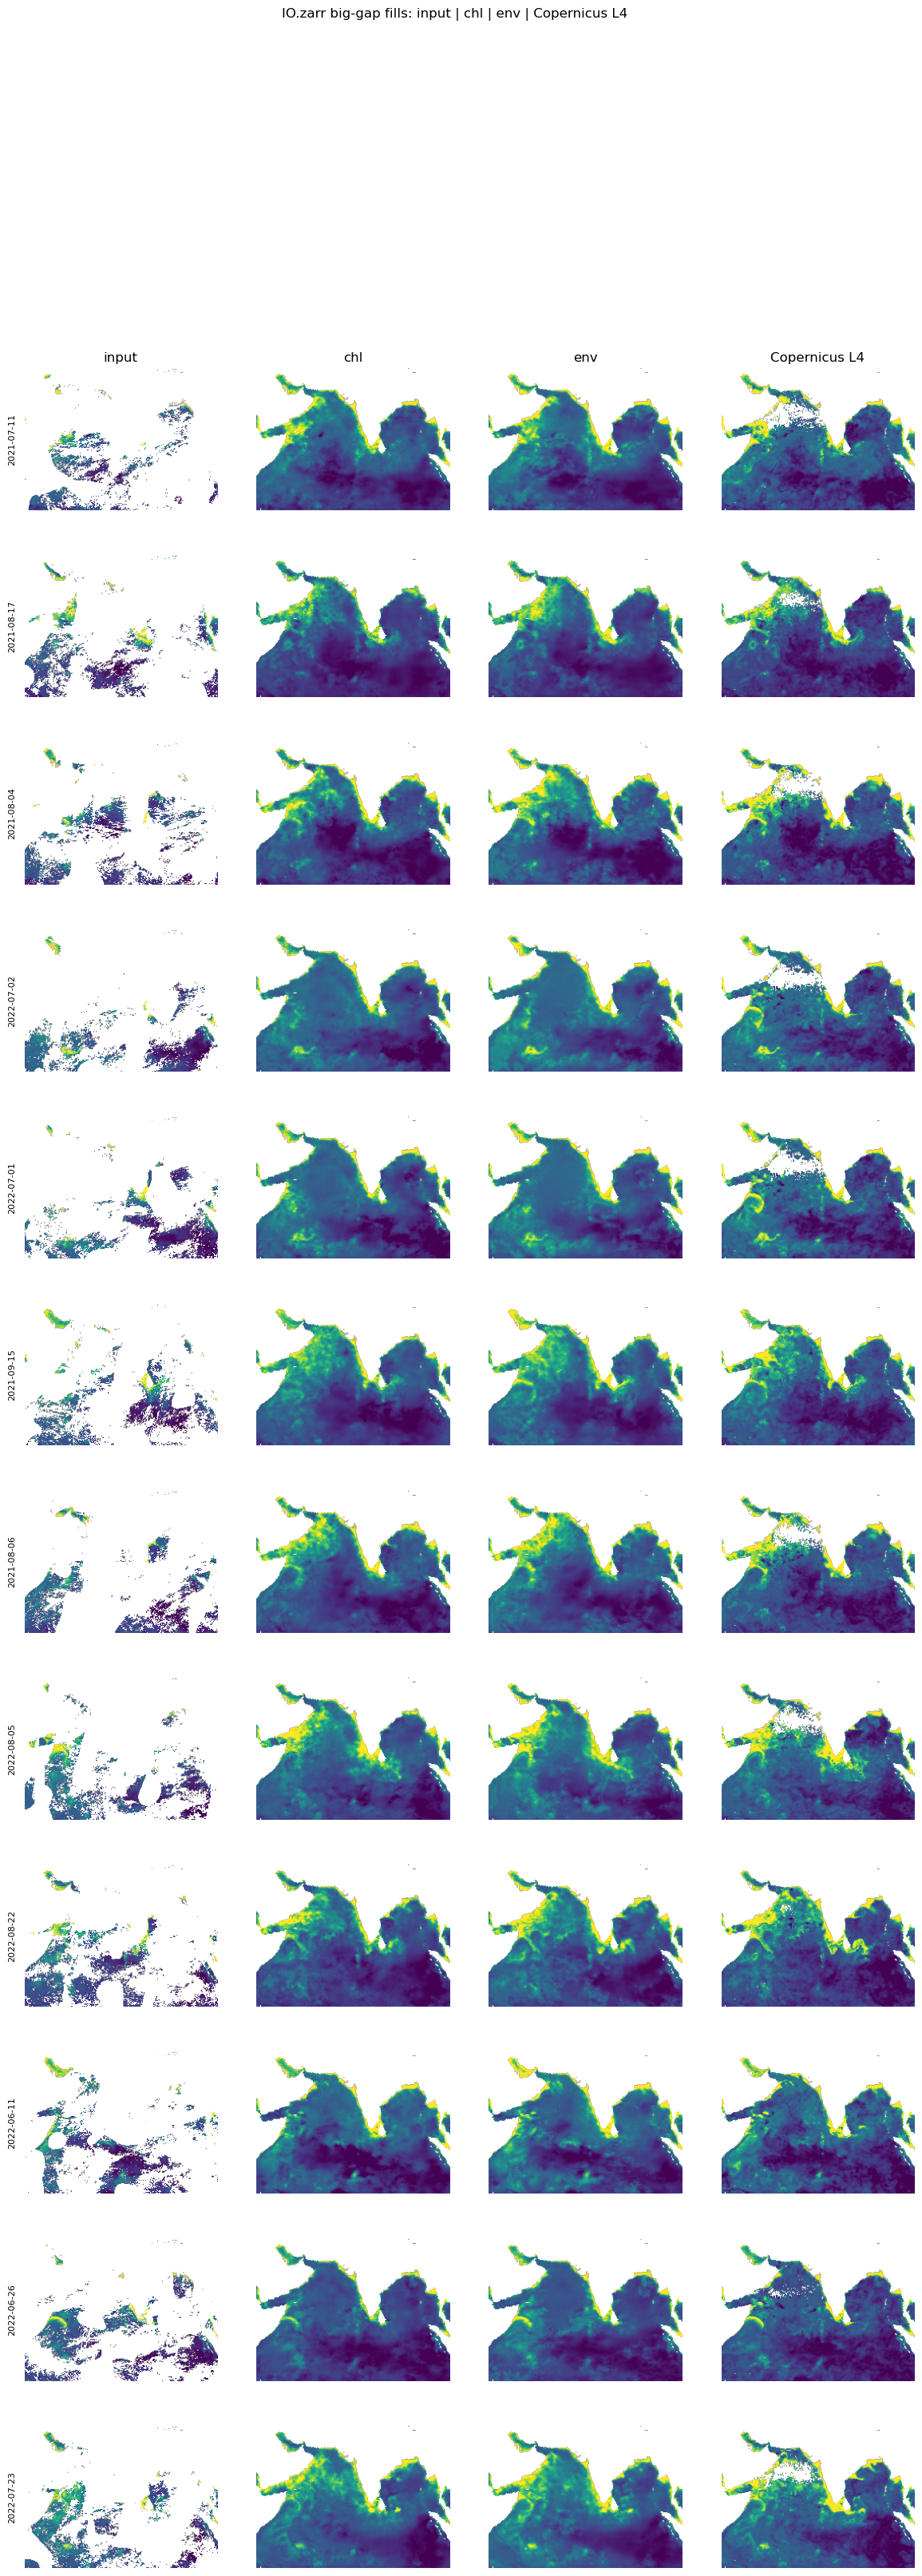

In [9]:
ng = sorted(val, key=lambda dd: int((~np.isfinite(chl_log[dd]) & ocean).sum()), reverse=True)[:12]
def cols_for(dd):
    tr_d = chl_log[dd]
    c = [("input", np.where(np.isfinite(tr_d) & ~fake[dd], tr_d, np.nan)),
         ("chl", np.where(ocean, pred["chl"][dd], np.nan)),
         ("env", np.where(ocean, pred["env"][dd], np.nan))]
    if filled_log is not None:
        c.append(("Copernicus L4", np.where(ocean, filled_log[dd], np.nan)))
    return c
ncol = len(cols_for(ng[0]))
fig, axes = plt.subplots(len(ng), ncol, figsize=(3.6 * ncol, 3.0 * len(ng)), squeeze=False)
for row, dd in enumerate(ng):
    tr_d = chl_log[dd]
    lo, hi = np.nanpercentile(tr_d[ocean][np.isfinite(tr_d[ocean])], [2, 98])
    for col, (nm, arr) in enumerate(cols_for(dd)):
        axes[row, col].imshow(arr, cmap="viridis", vmin=lo, vmax=hi, origin="upper"); axes[row, col].axis("off")
        if row == 0: axes[row, col].set_title(nm, fontsize=12)
    axes[row, 0].text(-0.04, 0.5, str(pd.to_datetime(times[dd]).date()), transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=8)
plt.suptitle("IO.zarr big-gap fills: " + " | ".join(nm for nm, _ in cols_for(ng[0])), y=1.003)
save_png("io_env_biggap_12.png", dpi=110, bbox_inches="tight"); plt.show()

### Four-panel view per model (one day)

The same layout as the earlier IO.zarr notebooks, for a single high-gap day: the observed level-3 field, the
land / cloud / fake-cloud flags, the model fill over ocean, and the observed-minus-predicted difference. One
figure per model, so `chl` and `env` are directly comparable on the same day and color scale. The difference
uses a blue-red diverging map (blue = observed higher, red = predicted higher) with the direction labeled, so
it reads without relying on a red-green distinction.

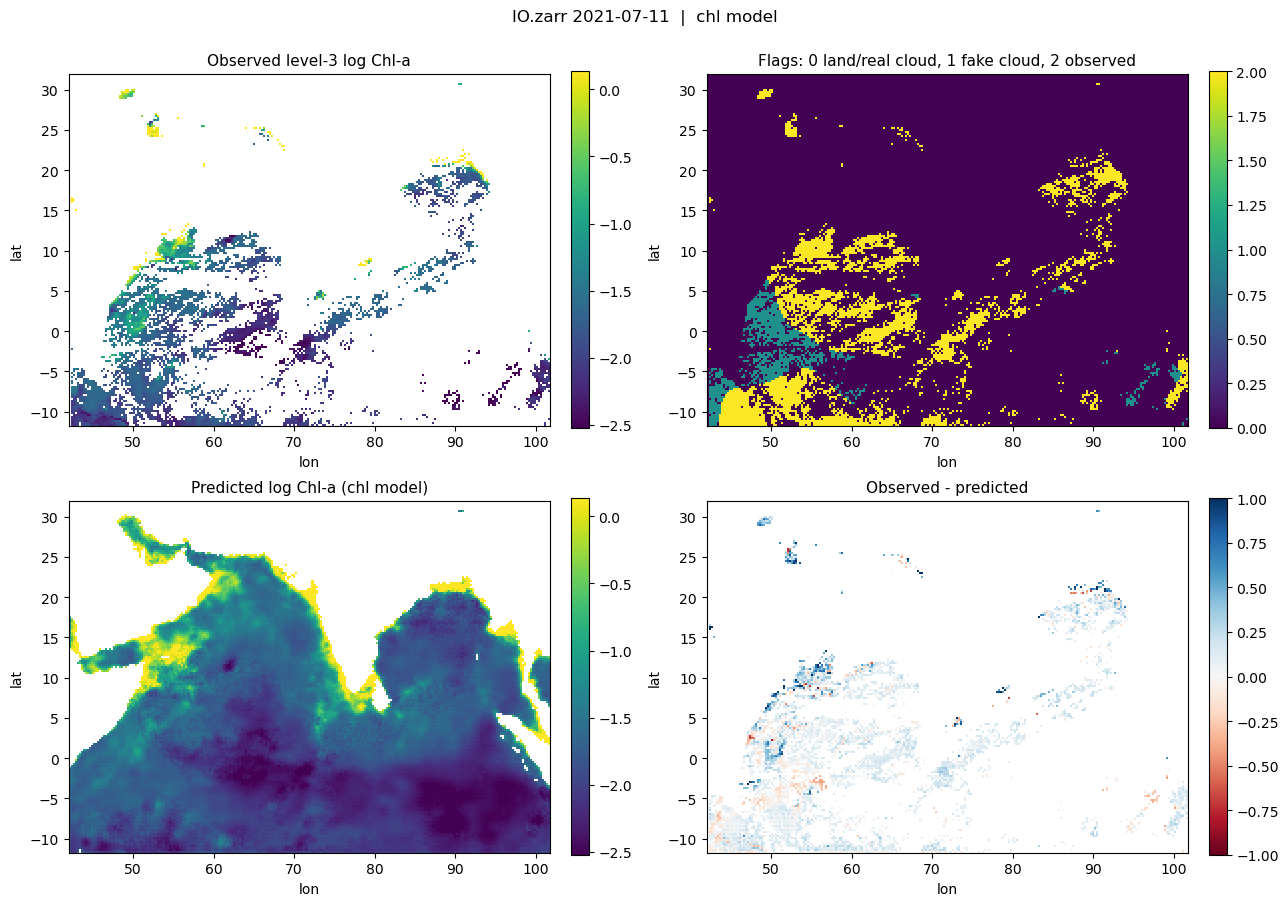

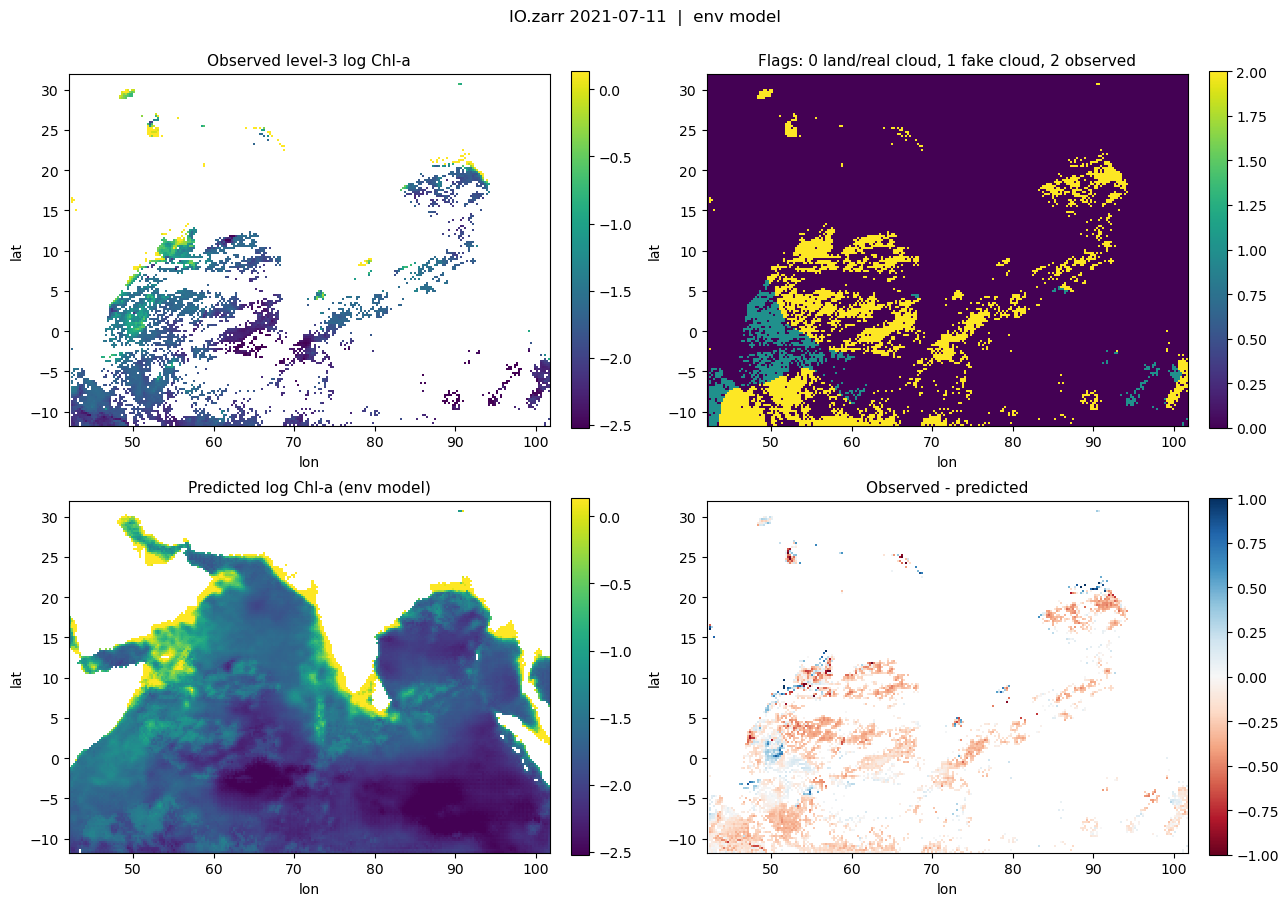

In [10]:
d4 = int(sorted(val, key=lambda dd: int((~np.isfinite(chl_log[dd]) & ocean).sum()), reverse=True)[0])
EXT = [float(LONV.min()), float(LONV.max()), float(LATV.min()), float(LATV.max())]

def plot_4panel(cfg, d):
    truth = chl_log[d]
    obs = np.where(ocean & np.isfinite(truth), truth, np.nan)
    predicted = np.where(ocean, pred[cfg][d], np.nan)
    diff = np.where(ocean & np.isfinite(truth), truth - pred[cfg][d], np.nan)
    flag = np.zeros((H, W), np.float32)
    flag = np.where(ocean & np.isfinite(truth), 2.0, flag)   # observed after masking
    flag = np.where(fake[d], 1.0, flag)                      # fake cloud (held-out); land and real cloud stay 0
    vlo, vhi = np.nanpercentile(obs[np.isfinite(obs)], [2, 98])
    fig, ax = plt.subplots(2, 2, figsize=(13, 9))
    panels = [(ax[0, 0], obs, vlo, vhi, "viridis", "Observed level-3 log Chl-a"),
              (ax[0, 1], flag, 0, 2, "viridis", "Flags: 0 land/real cloud, 1 fake cloud, 2 observed"),
              (ax[1, 0], predicted, vlo, vhi, "viridis", f"Predicted log Chl-a ({cfg} model)"),
              (ax[1, 1], diff, -1, 1, "RdBu", "Observed - predicted")]
    for a, arr, lo, hi, cm, ttl in panels:
        im = a.imshow(arr, vmin=lo, vmax=hi, cmap=cm, extent=EXT, origin="upper", interpolation="nearest")
        a.set_title(ttl, size=11); a.set_xlabel("lon"); a.set_ylabel("lat")
        fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
    fig.suptitle(f"IO.zarr {str(pd.to_datetime(times[d]).date())}  |  {cfg} model", y=1.0)
    plt.tight_layout(); save_png(f"io_4panel_{cfg}.png", dpi=120, bbox_inches="tight"); plt.show()

for cfg in ["chl", "env"]:
    plot_4panel(cfg, d4)

## Read

The number to watch is whether `env` beats `chl` on held-out MAE, and whether the `env` fill carries SST-like
structure into the large gaps where `chl` flattens to a smooth mean. A win for `env` supports the reading that
the smudging on PACE and Copernicus is a missing-predictor problem (no SST or winds in those stores) rather
than a code regression, and that the earlier IO.zarr models looked better in part because they had these
inputs. A tie supports the smudging being intrinsic to the MSE gap-fill, which points at the loss or the model
as the next lever, in line with the ideas discussed with Valentina.